# Image Augmentation Techniques with Albumentations

**Stack:** Albumentations + PyTorch | **Dataset:** CIFAR-10 |

Imagine you're training a model to recognise cats. You only have 1,000 cat photos. A cat lying down, a cat photographed from the right, a slightly blurry cat — these are all still cats, but your model has never seen them. It will fail.

**Image augmentation** solves this by creating modified versions of your existing images on the fly during training. The model never sees the same image twice — it sees the original and endless realistic variations of it.

**Albumentations** is the fastest and most flexible augmentation library available. It's significantly faster than torchvision transforms and has 70+ transform types.

---

### What we cover
1. Setup & CIFAR-10 loading
2. Spatial transforms catalog — flips, rotations, crops
3. Pixel-level transforms catalog — brightness, blur, noise
4. Advanced transforms — cutout, grid distortion, elastic
5. Composing a realistic augmentation pipeline
6. Training comparison: No augmentation vs With augmentation
7. Results & when to use what

In [32]:
# Install albumentations if not already available
!pip install albumentations -q

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Albumentations : {A.__version__}')
print(f'PyTorch        : {torch.__version__}')
print(f'Device         : {DEVICE}')

Albumentations : 2.0.8
PyTorch        : 2.9.0+cu126
Device         : cuda


---
## 1. Load CIFAR-10

CIFAR-10 has 60,000 colour images (32×32 pixels) across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

We load it using torchvision (without any transforms for now) and keep the raw numpy arrays so Albumentations can work with them — Albumentations expects `numpy` images in `HWC` format (Height × Width × Channels), not PyTorch tensors.

In [33]:
from torchvision import datasets, transforms

# Load raw data — no transforms, we'll handle everything with Albumentations
raw_train = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transforms.ToTensor())
raw_test  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f'Train samples : {len(raw_train):,}')
print(f'Test samples  : {len(raw_test):,}')
print(f'Image shape   : {raw_train[0][0].shape}  (C × H × W)')
print(f'Classes       : {CLASS_NAMES}')

Train samples : 50,000
Test samples  : 10,000
Image shape   : torch.Size([3, 32, 32])  (C × H × W)
Classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


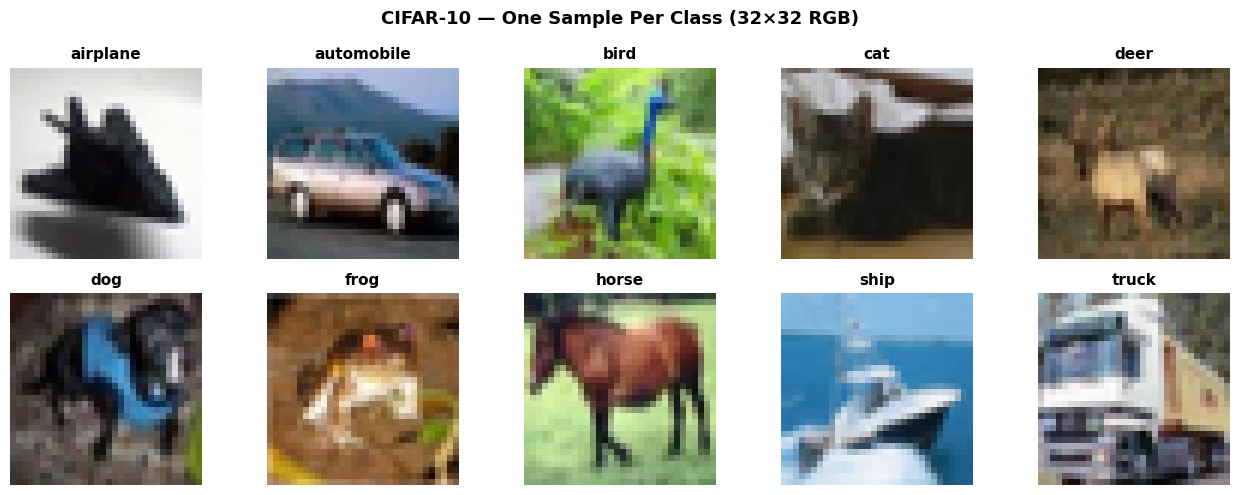

In [34]:
# Peek at the dataset — one image per class
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
shown = {}

for img_tensor, label in raw_train:
    if label not in shown:
        shown[label] = img_tensor.permute(1, 2, 0).numpy()  # CHW → HWC
    if len(shown) == 10:
        break

for ax, (label, img) in zip(axes.flatten(), sorted(shown.items())):
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[label], fontweight='bold', fontsize=11)
    ax.axis('off')

plt.suptitle('CIFAR-10 — One Sample Per Class (32×32 RGB)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
# Helper: get a single image as numpy HWC uint8 (what Albumentations expects)
def get_numpy_image(dataset, idx):
    img_tensor, label = dataset[idx]
    img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return img_np, label

# Helper: show original + N augmented versions side by side
def show_augmented(transform, dataset, idx, n_cols=6, title=''):
    img, label = get_numpy_image(dataset, idx)
    fig, axes = plt.subplots(1, n_cols + 1, figsize=(3 * (n_cols+1), 3.2))

    axes[0].imshow(img)
    axes[0].set_title('Original', fontweight='bold', fontsize=10)
    axes[0].axis('off')

    for i in range(1, n_cols + 1):
        aug_img = transform(image=img)['image']
        axes[i].imshow(aug_img)
        axes[i].set_title(f'Aug #{i}', fontsize=9)
        axes[i].axis('off')

    plt.suptitle(f'{title}  |  Class: {CLASS_NAMES[label]}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Helper functions ready.')
# Fix random seed for reproducible demos
DEMO_IDX = 6   # a frog image

Helper functions ready.


---
## 2. Spatial Transforms — Moving Pixels Around

Spatial transforms change **where** pixels are in the image — flipping, rotating, scaling, cropping. They simulate the same object being photographed from different positions and angles.

**Key property:** These transforms preserve the visual content but change its position/orientation. They're almost always safe to apply to any image dataset.

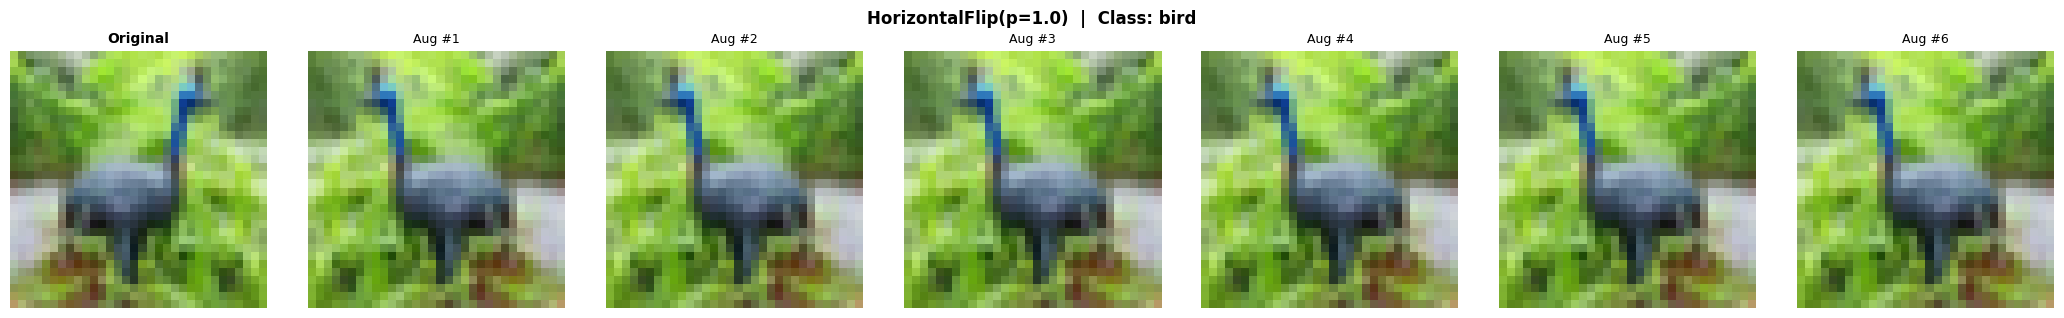

In [36]:
# --- HorizontalFlip ---
# Mirrors the image left-to-right.
# Safe for: animals, vehicles, nature. Avoid for: text, medical scans with left/right meaning.
# p=0.5 means 50% chance of applying on each image.

show_augmented(
    A.HorizontalFlip(p=1.0),
    raw_train, DEMO_IDX,
    title='HorizontalFlip(p=1.0)'
)

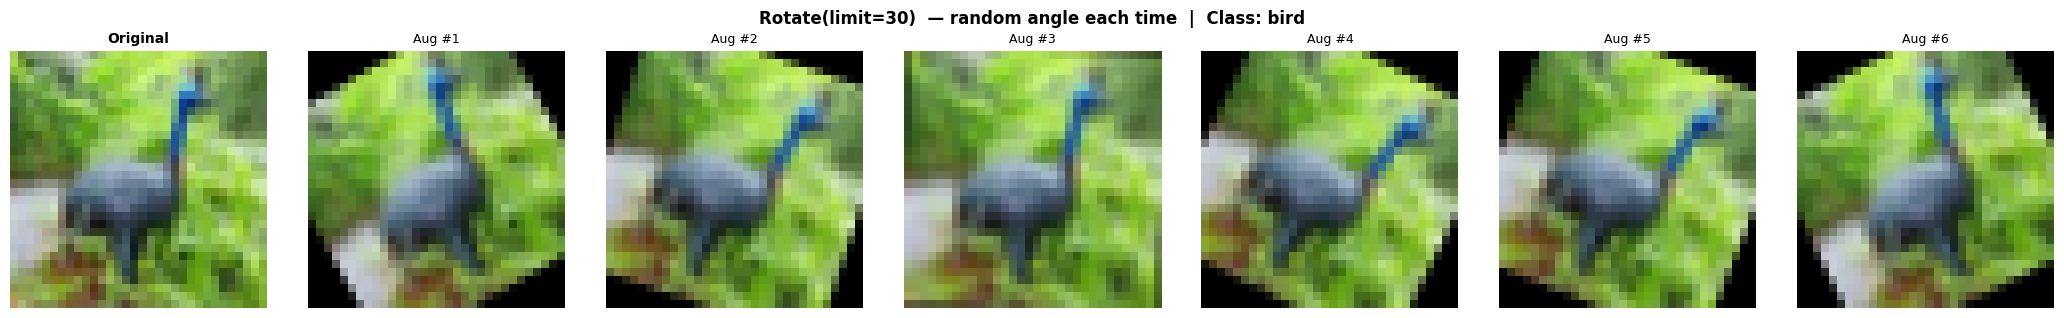

In [37]:
# --- Rotate ---
# Rotates the image by a random angle within the given limit.
# limit=30 means anywhere from -30° to +30°.
# border_mode fills the empty corners — REFLECT mirrors the edge pixels inward.

show_augmented(
    A.Rotate(limit=30, border_mode=0, p=1.0),
    raw_train, DEMO_IDX,
    title='Rotate(limit=30)  — random angle each time'
)

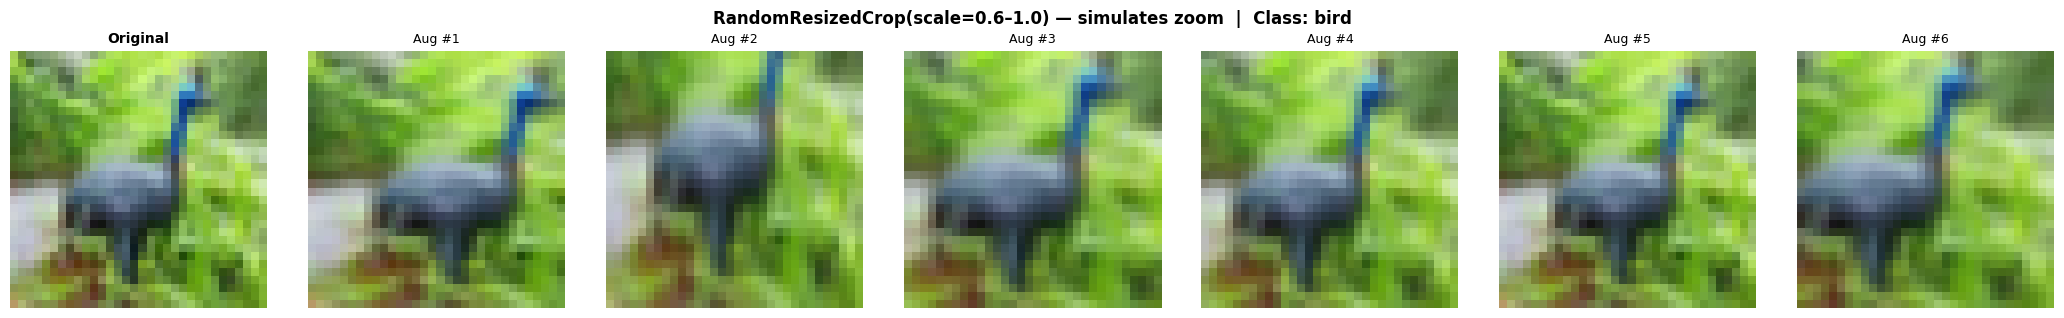

In [38]:
# --- RandomResizedCrop ---
# Crops a random portion of the image, then resizes back to original size.
# scale=(0.6, 1.0) means the crop covers 60%–100% of the original area.
# This is one of the most powerful augmentations — it forces the model to
# recognise objects at different scales and positions (zoom invariance).

show_augmented(
    A.RandomResizedCrop(size=(32, 32), scale=(0.6, 1.0), p=1.0),
    raw_train, DEMO_IDX,
    title='RandomResizedCrop(scale=0.6–1.0) — simulates zoom'
)

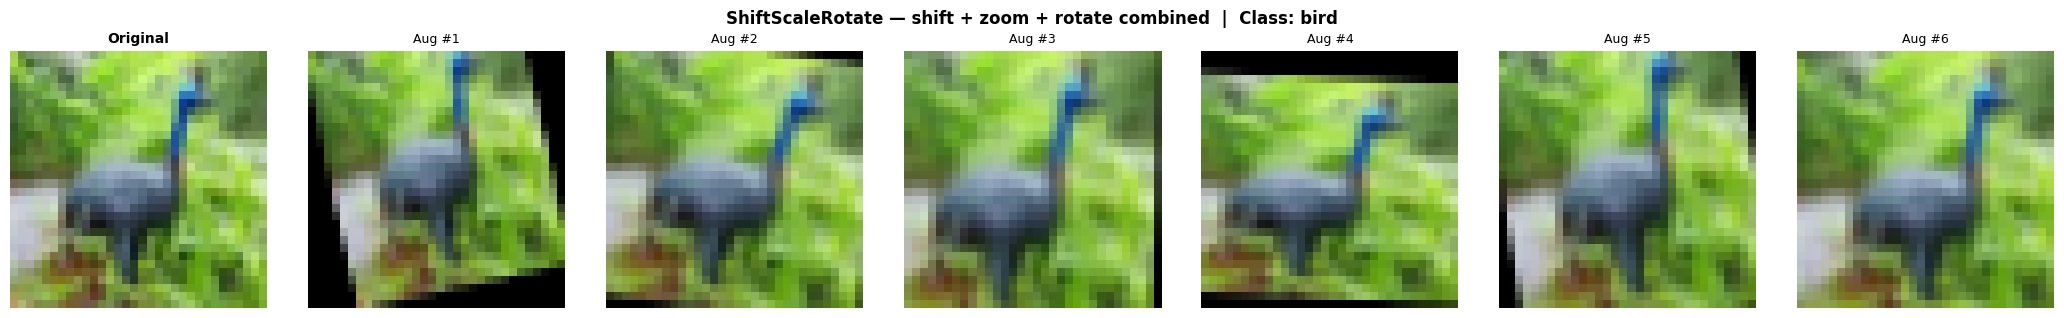

In [39]:
# --- ShiftScaleRotate ---
# Combines three spatial transforms in one:
#   shift_limit  = how much to translate the image (fraction of image size)
#   scale_limit  = how much to zoom in/out
#   rotate_limit = rotation range in degrees
# Very efficient — one transform call does three things at once.

show_augmented(
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=20,
                       border_mode=0, p=1.0),
    raw_train, DEMO_IDX,
    title='ShiftScaleRotate — shift + zoom + rotate combined'
)

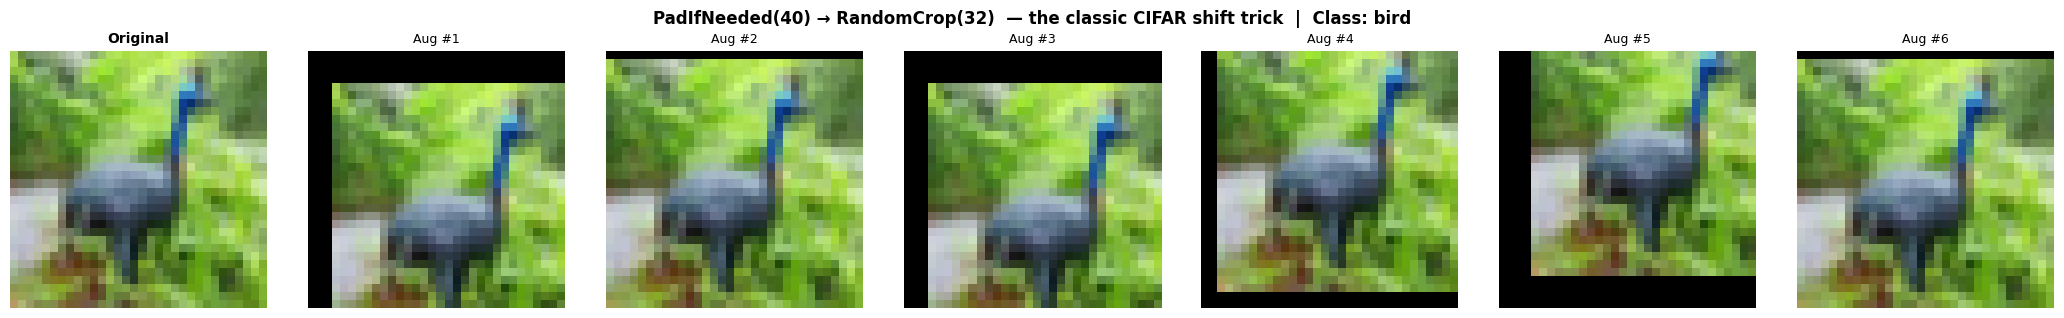

In [40]:
# --- Padding then Crop (the classic CIFAR trick) ---
# Pad 4 pixels on every side, then randomly crop back to 32×32.
# This subtly shifts the image content up/down/left/right.
# Cheap to compute, surprisingly effective on CIFAR.

pad_then_crop = A.Compose([
    A.PadIfNeeded(min_height=40, min_width=40, border_mode=0, value=0),
    A.RandomCrop(height=32, width=32)
])
show_augmented(pad_then_crop, raw_train, DEMO_IDX,
               title='PadIfNeeded(40) → RandomCrop(32)  — the classic CIFAR shift trick')

---
## 3. Pixel-Level Transforms — Changing Colour & Texture

Pixel transforms change **what value** each pixel has — brightness, contrast, colour, blur, noise — but the spatial layout stays the same. They simulate:
- Different lighting conditions (brightness, contrast)
- Different cameras or sensors (noise, compression)
- Motion or focus blur (camera shake, depth of field)

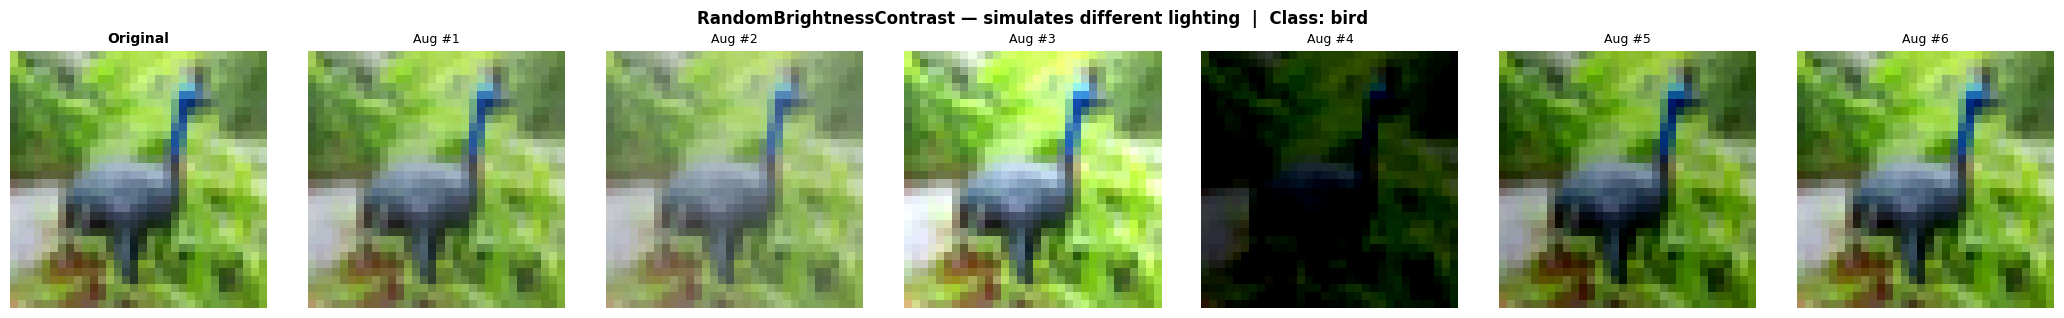

In [41]:
# --- RandomBrightnessContrast ---
# brightness_limit=0.3 → brightness multiplier randomly in [0.7, 1.3]
# contrast_limit=0.3   → contrast multiplier randomly in [0.7, 1.3]
# Simulates different lighting conditions — overcast vs bright sun.

show_augmented(
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=1.0),
    raw_train, DEMO_IDX,
    title='RandomBrightnessContrast — simulates different lighting'
)

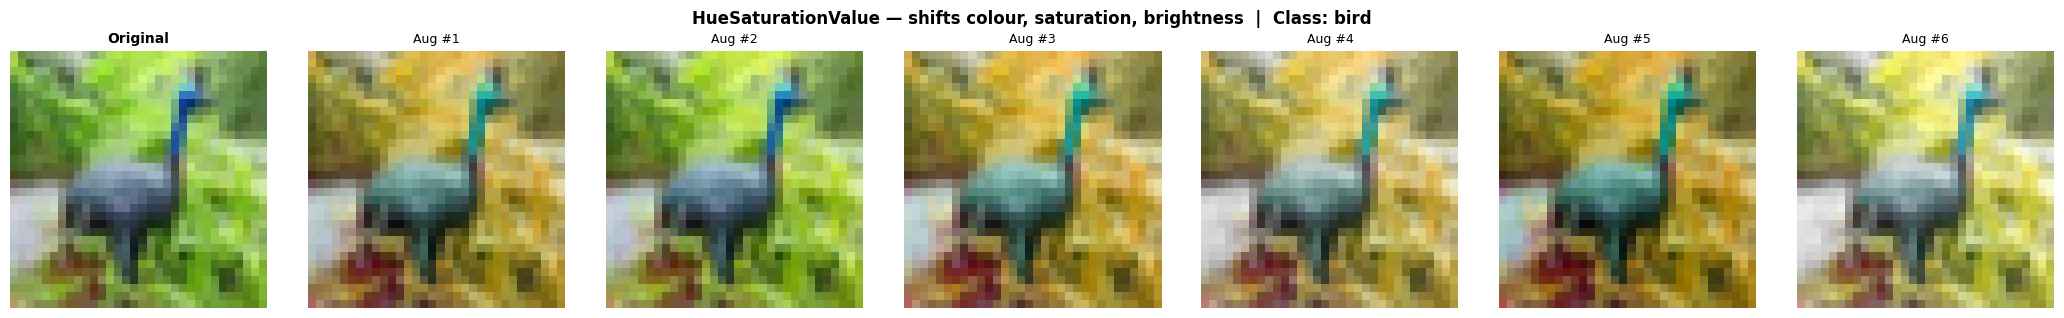

In [42]:
# --- HueSaturationValue ---
# Randomly shifts hue (colour), saturation (intensity), and value (brightness).
# hue_shift_limit=20 → hue shifts by ±20° on the colour wheel
# Useful when colour varies naturally (different animal coat colours, season changes).
# Avoid for tasks where exact colour is meaningful (e.g. medical histology staining).

show_augmented(
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=40, val_shift_limit=20, p=1.0),
    raw_train, DEMO_IDX,
    title='HueSaturationValue — shifts colour, saturation, brightness'
)

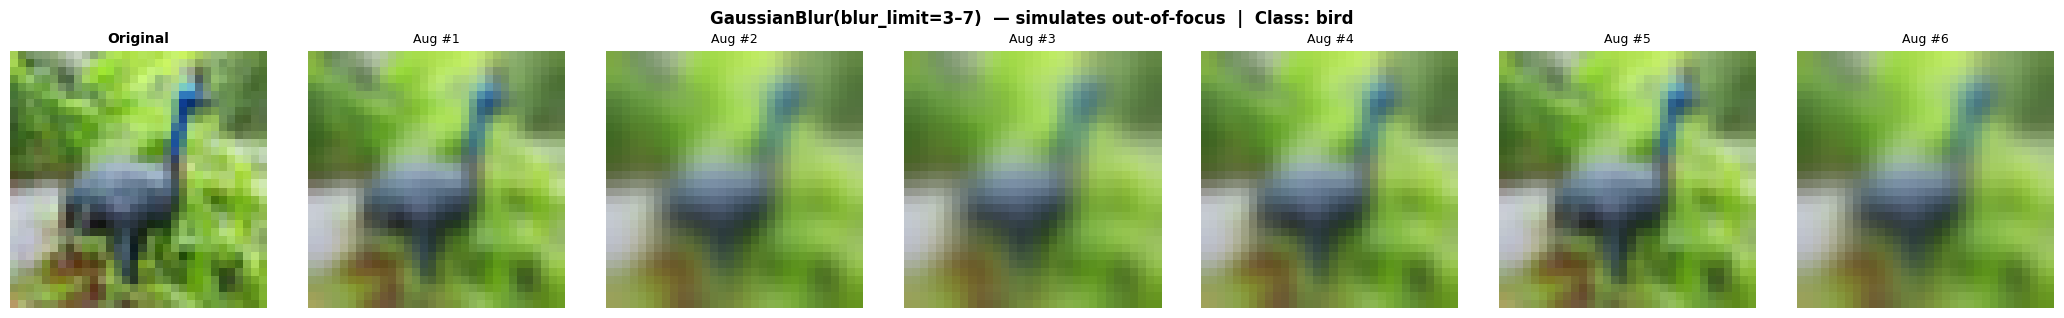

In [43]:
# --- GaussianBlur ---
# Applies a Gaussian blur kernel. blur_limit=(3,7) means kernel size randomly chosen
# from 3×3 to 7×7. Simulates camera out-of-focus or motion blur.
# Note: too much blur destroys useful features — keep sigma small.

show_augmented(
    A.GaussianBlur(blur_limit=(3, 7), p=1.0),
    raw_train, DEMO_IDX,
    title='GaussianBlur(blur_limit=3–7)  — simulates out-of-focus'
)

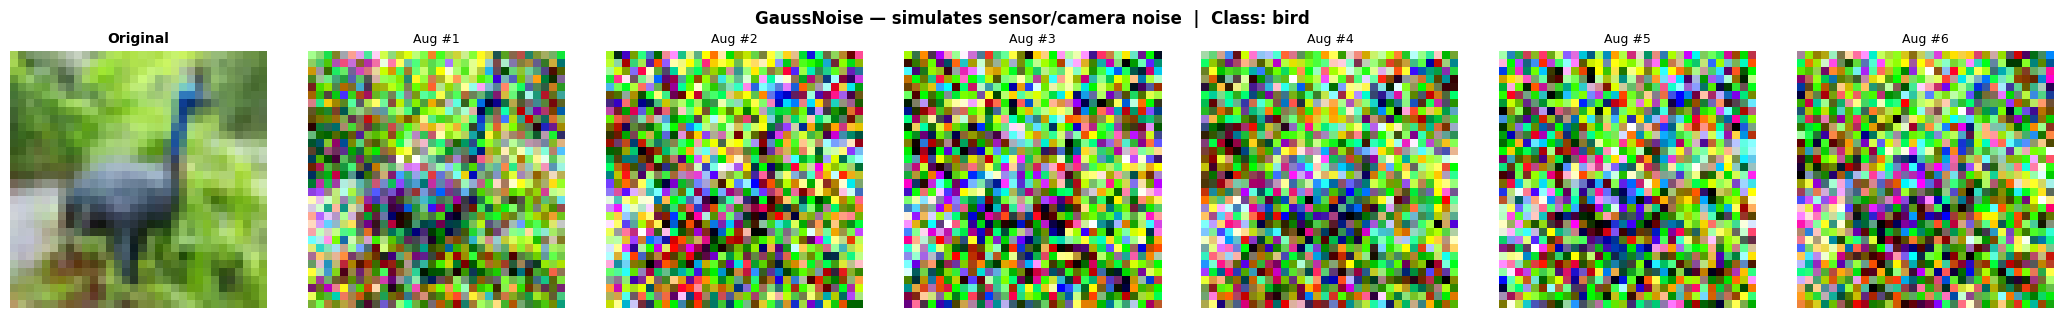

In [44]:
# --- GaussNoise ---
# Adds random Gaussian noise to each pixel.
# var_limit=(10, 50) controls the variance of the noise.
# Simulates sensor noise from low-quality cameras or low-light conditions.

show_augmented(
    A.GaussNoise(var_limit=(20, 80), p=1.0),
    raw_train, DEMO_IDX,
    title='GaussNoise — simulates sensor/camera noise'
)

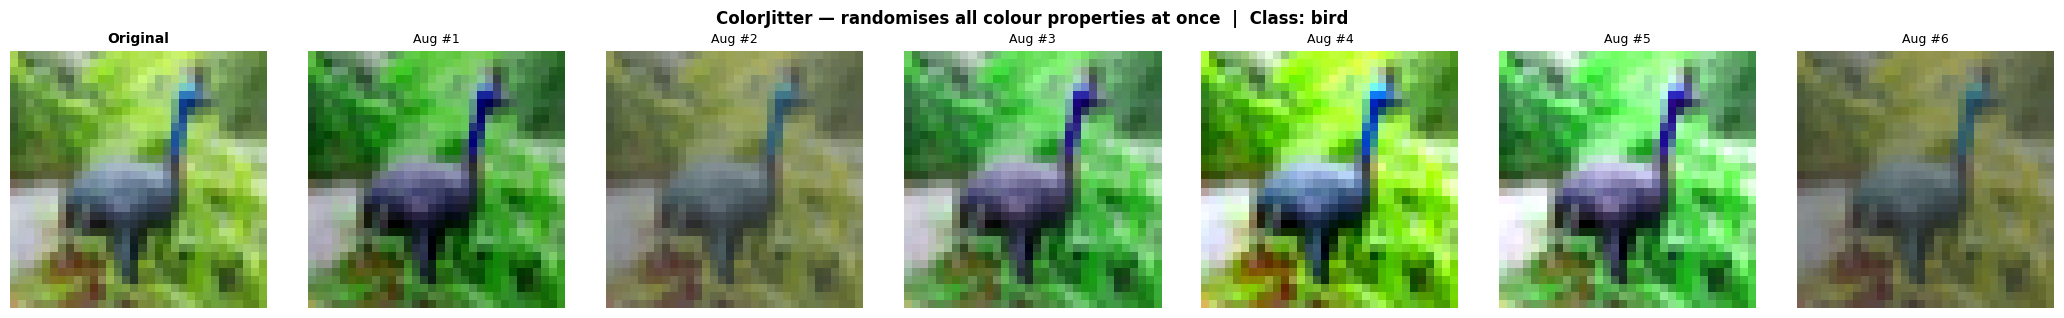

In [45]:
# --- ColorJitter ---
# One-stop shop for colour augmentation. Randomly changes brightness,
# contrast, saturation, and hue in one transform.
# Similar to torchvision's ColorJitter but Albumentations version is faster.

show_augmented(
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=1.0),
    raw_train, DEMO_IDX,
    title='ColorJitter — randomises all colour properties at once'
)

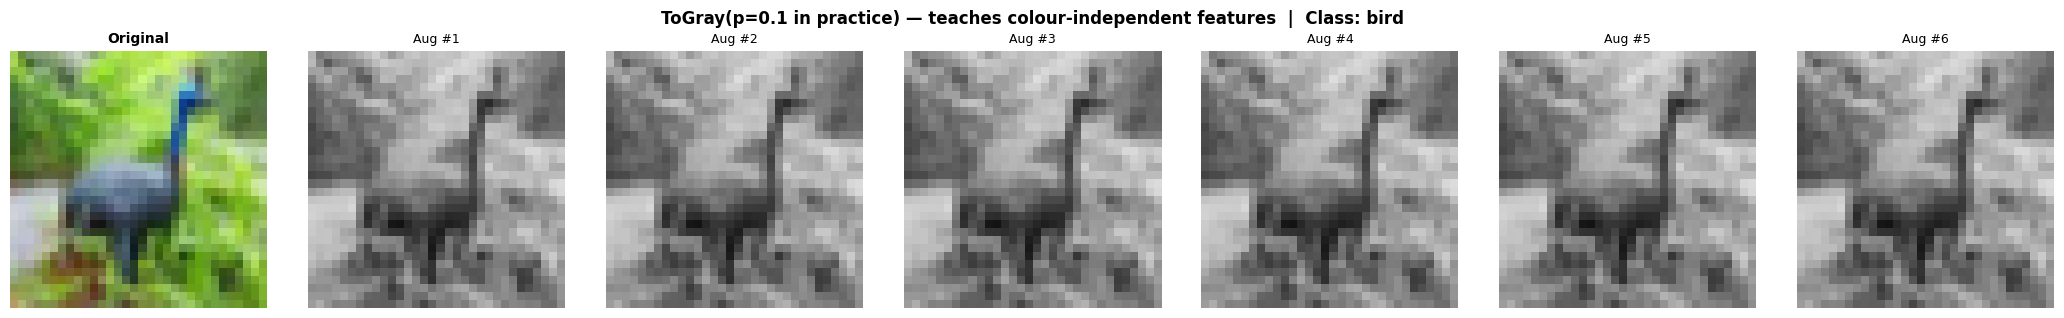

In [46]:
# --- ToGray ---
# Converts image to grayscale (but keeps 3 channels by repeating the gray channel).
# Useful when colour isn't always available at inference time.
# Apply with low probability — you don't want all training images to be gray.

show_augmented(
    A.ToGray(p=1.0),
    raw_train, DEMO_IDX,
    title='ToGray(p=0.1 in practice) — teaches colour-independent features'
)

---
## 4. Advanced Transforms — Structural Distortions & Occlusion

These go beyond simple spatial/colour changes and simulate more complex real-world effects. They're particularly powerful for getting the last few percent of accuracy, but need to be used carefully — too aggressive and they destroy the label.

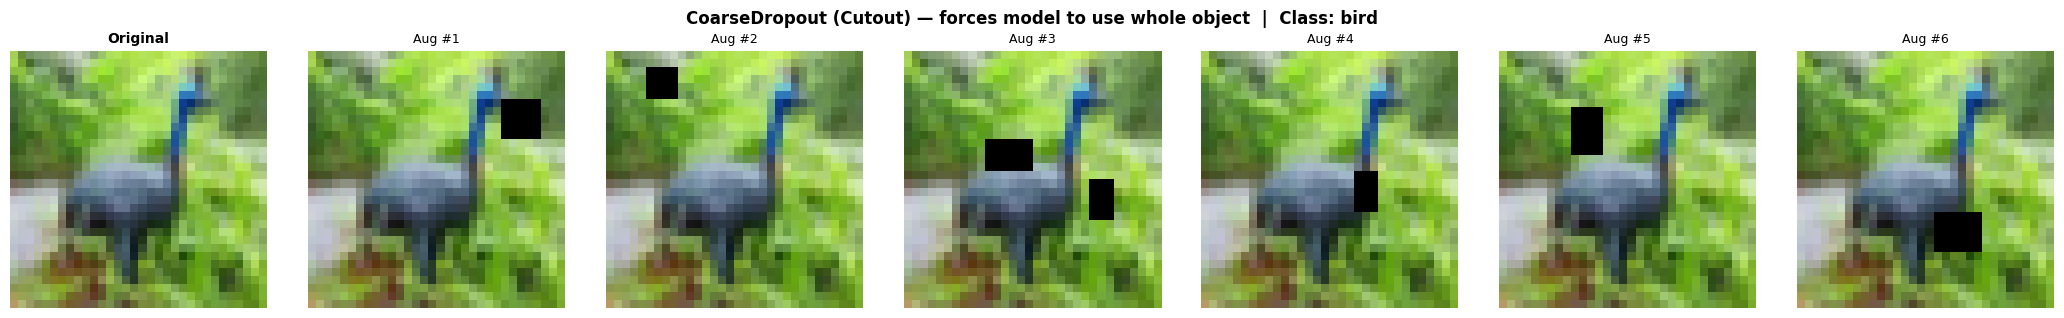

In [47]:
# --- CoarseDropout (Cutout) ---
# Randomly erases rectangular regions of the image by filling them with zeros (black).
# This forces the model to not rely on any single region — it must learn the
# whole object, not just the most discriminative patch.
# A dog model that only looked at ears would fail when an ear is cut out.
# max_holes: how many rectangles to cut
# max_height/width: maximum size of each rectangle

show_augmented(
    A.CoarseDropout(max_holes=4, max_height=8, max_width=8,
                    min_holes=1, fill_value=0, p=1.0),
    raw_train, DEMO_IDX,
    title='CoarseDropout (Cutout) — forces model to use whole object'
)

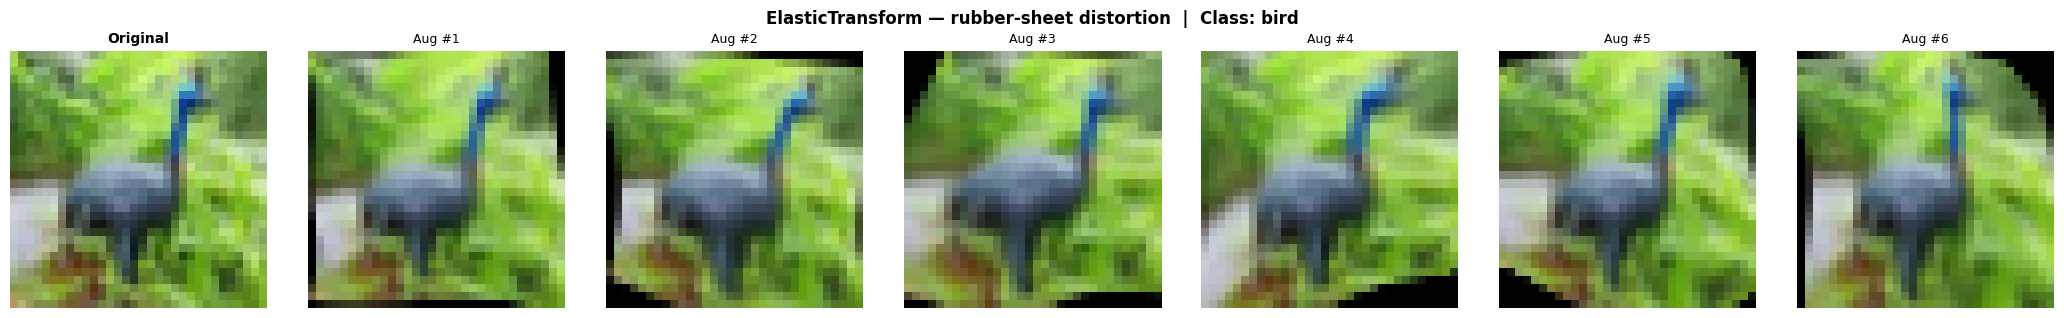

In [48]:
# --- ElasticTransform ---
# Applies a smooth, wavy distortion to the image — like stretching a rubber sheet.
# alpha controls the intensity of the distortion.
# sigma controls the smoothness (higher = smoother waves).
# Classic in medical imaging (cell shapes vary), also helps with handwriting.

show_augmented(
    A.ElasticTransform(alpha=60, sigma=6, alpha_affine=10, border_mode=0, p=1.0),
    raw_train, DEMO_IDX,
    title='ElasticTransform — rubber-sheet distortion'
)

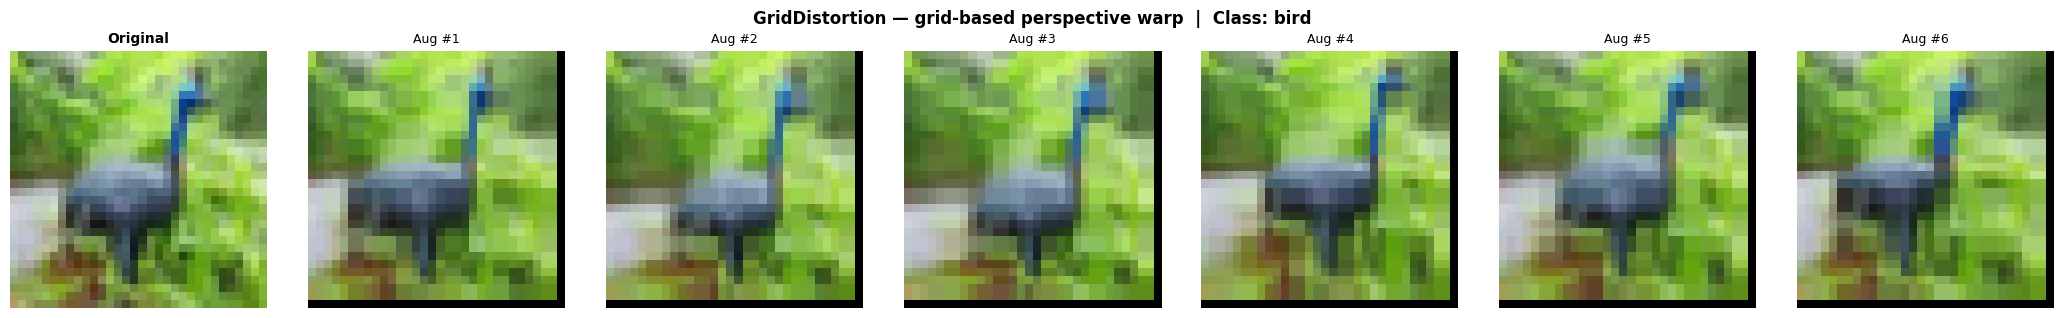

In [49]:
# --- GridDistortion ---
# Divides the image into a grid and randomly distorts each cell.
# Creates perspective-like warping. num_steps controls grid density.
# distort_limit controls how extreme the distortion is.

show_augmented(
    A.GridDistortion(num_steps=5, distort_limit=0.3, border_mode=0, p=1.0),
    raw_train, DEMO_IDX,
    title='GridDistortion — grid-based perspective warp'
)

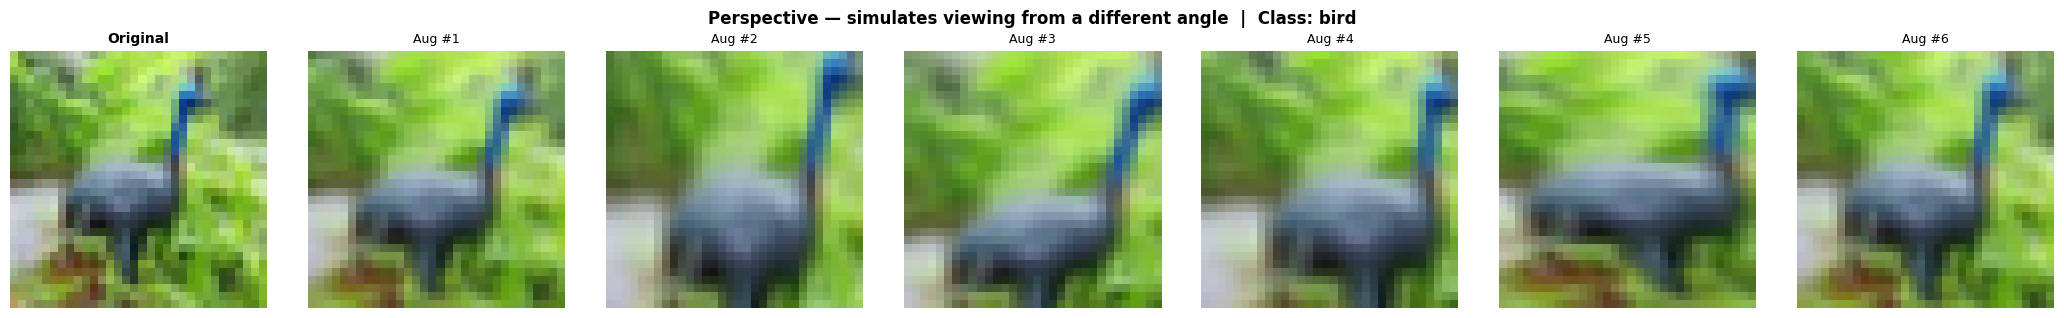

In [50]:
# --- Perspective ---
# Simulates viewing the image from a different angle by applying a
# perspective (projective) transform. scale controls how extreme the tilt is.
# Useful when objects can be viewed from different angles at inference.

show_augmented(
    A.Perspective(scale=(0.05, 0.15), p=1.0),
    raw_train, DEMO_IDX,
    title='Perspective — simulates viewing from a different angle'
)

---
## 5. Complete Augmentation Catalog — All in One View

One visual reference showing every transform we covered, applied to the same image.

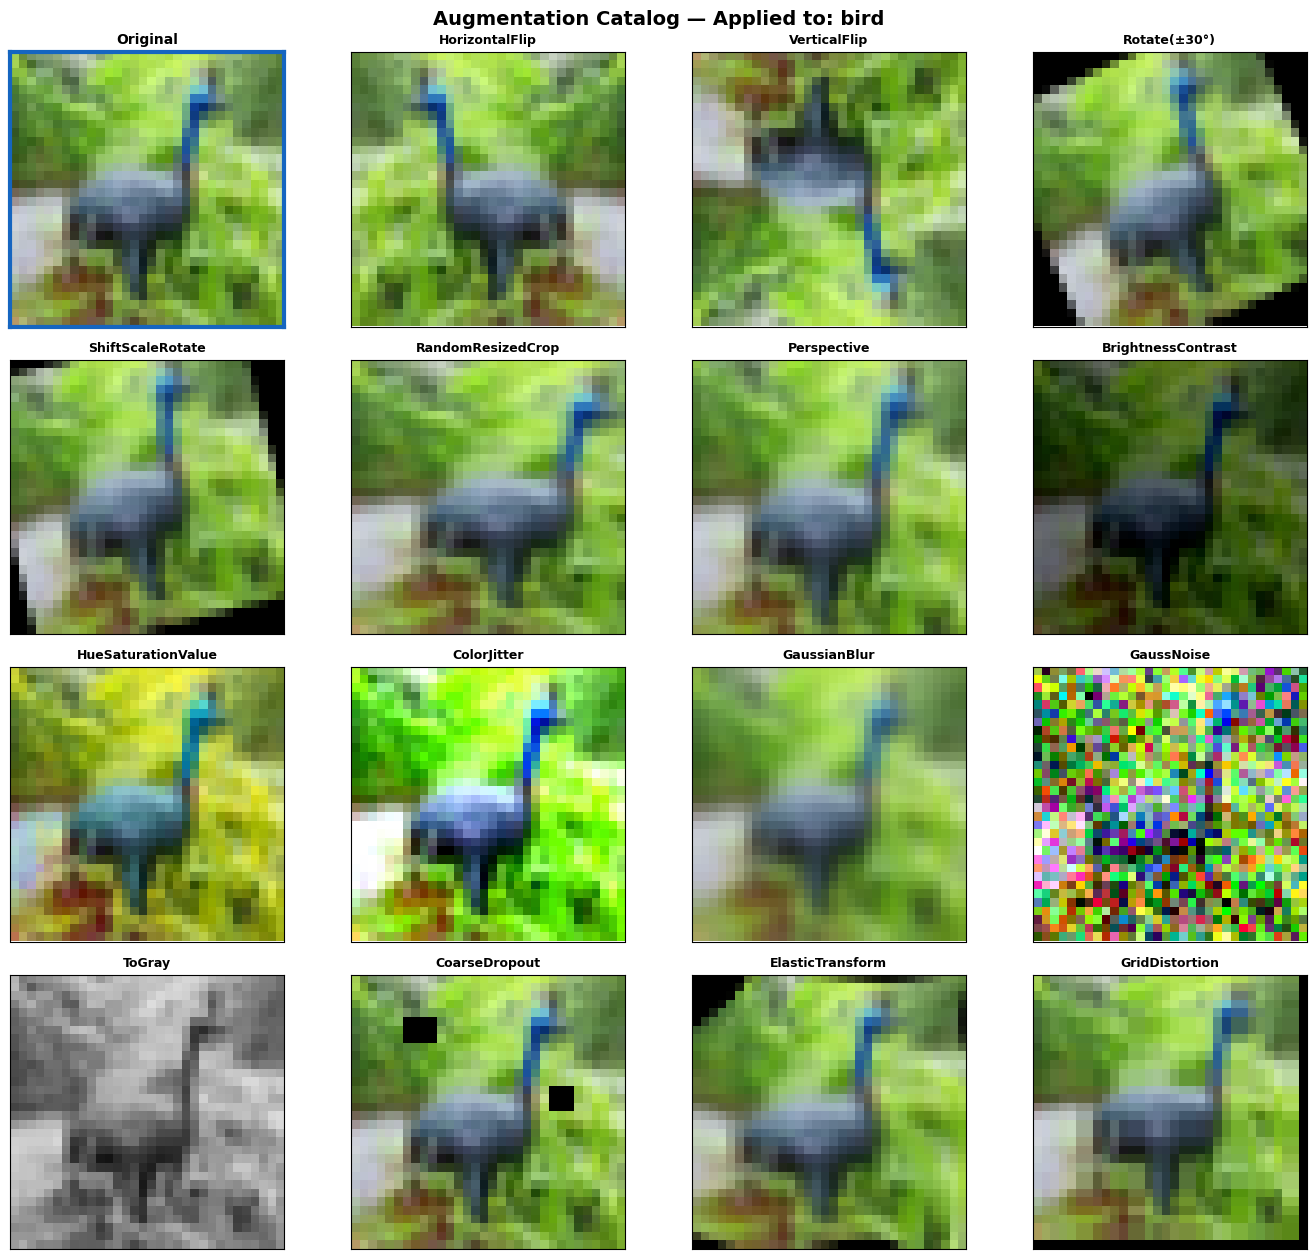

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A

img, label = get_numpy_image(raw_train, DEMO_IDX)

catalog = [
    ('Original', None),

    ('HorizontalFlip',
     A.HorizontalFlip(p=1.0)),

    ('VerticalFlip',
     A.VerticalFlip(p=1.0)),

    ('Rotate(±30°)',
     A.Rotate(limit=30, border_mode=0, p=1.0)),

    ('ShiftScaleRotate',
     A.ShiftScaleRotate(
         shift_limit=0.15,
         scale_limit=0.2,
         rotate_limit=25,
         border_mode=0,
         p=1.0
     )),

    ('RandomResizedCrop',
     A.RandomResizedCrop(
         size=(32, 32),
         scale=(0.6, 1.0),
         p=1.0
     )),

    ('Perspective',
     A.Perspective(scale=(0.05, 0.15), p=1.0)),

    ('BrightnessContrast',
     A.RandomBrightnessContrast(
         brightness_limit=0.4,
         contrast_limit=0.4,
         p=1.0
     )),

    ('HueSaturationValue',
     A.HueSaturationValue(
         hue_shift_limit=20,
         sat_shift_limit=40,
         val_shift_limit=20,
         p=1.0
     )),

    ('ColorJitter',
     A.ColorJitter(
         brightness=0.3,
         contrast=0.3,
         saturation=0.3,
         hue=0.1,
         p=1.0
     )),

    ('GaussianBlur',
     A.GaussianBlur(
         blur_limit=(3, 7),
         p=1.0
     )),

    ('GaussNoise',
     A.GaussNoise(
         var_limit=(20.0, 80.0),
         p=1.0
     )),

    ('ToGray',
     A.ToGray(p=1.0)),

    ('CoarseDropout',
     A.CoarseDropout(
         max_holes=4,
         max_height=8,
         max_width=8,
         min_holes=1,
         fill=0,
         p=1.0
     )),

    ('ElasticTransform',
     A.ElasticTransform(
         alpha=60,
         sigma=6,
         border_mode=0,
         p=1.0
     )),

    ('GridDistortion',
     A.GridDistortion(
         num_steps=5,
         distort_limit=0.3,
         border_mode=0,
         p=1.0
     )),
]

# ---- Plotting ----
n_cols = 4
n_rows = int(np.ceil(len(catalog) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.2))

np.random.seed(0)

for ax, (name, transform) in zip(axes.flatten(), catalog):
    if transform is None:
        disp = img
        ax.set_title('Original', fontweight='bold', fontsize=10, color='black')
        for spine in ax.spines.values():
            spine.set_edgecolor('#1565C0')
            spine.set_linewidth(3)
    else:
        disp = transform(image=img)['image']
        ax.set_title(name, fontsize=9, fontweight='bold')

    ax.imshow(disp)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused axes
for ax in axes.flatten()[len(catalog):]:
    ax.axis('off')

plt.suptitle(
    f'Augmentation Catalog — Applied to: {CLASS_NAMES[label]}',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---
## 6. Building a Real Pipeline with `A.Compose`

In practice you never apply just one transform. You compose several together, each with its own probability. `A.Compose` applies them in sequence. `A.OneOf` picks one randomly from a group — useful when you want variety without stacking too many heavy transforms.

**Golden rule for pipeline design:**
- Spatial transforms (flip, rotate, crop) — use high probability (0.5–1.0)
- Colour transforms — use medium probability (0.3–0.5)
- Heavy distortions (elastic, dropout) — use low probability (0.1–0.3)
- Always end with `Normalize` + `ToTensorV2`

In [52]:
# CIFAR-10 dataset mean and std — computed from the training set
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

# --- Strong training pipeline ---
train_transform = A.Compose([
    # Spatial: almost always apply
    A.HorizontalFlip(p=0.5),
    A.PadIfNeeded(min_height=40, min_width=40, border_mode=0, value=0),
    A.RandomCrop(height=32, width=32),
    A.Rotate(limit=15, border_mode=0, p=0.3),

    # Colour: pick ONE of these per image
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    ], p=0.6),

    # Noise / blur: pick ONE occasionally
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5)),
        A.GaussNoise(var_limit=(10, 40)),
    ], p=0.2),

    # Occlusion: use sparingly
    A.CoarseDropout(max_holes=2, max_height=8, max_width=8,
                    min_holes=1, fill_value=0, p=0.2),

    # Always at the end: normalise + convert to tensor
    A.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
    ToTensorV2(),
])

# --- Baseline pipeline (no augmentation, just normalise) ---
baseline_transform = A.Compose([
    A.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
    ToTensorV2(),
])

# --- Test pipeline (never augment test images — only normalise) ---
test_transform = A.Compose([
    A.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
    ToTensorV2(),
])

print('Pipelines defined.')
print(f'Train augmented pipeline : {len(train_transform.transforms)} transform groups')
print(f'Baseline pipeline        : normalise + ToTensor only')
print(f'Test pipeline            : normalise + ToTensor only  (no augmentation at test time)')

Pipelines defined.
Train augmented pipeline : 9 transform groups
Baseline pipeline        : normalise + ToTensor only
Test pipeline            : normalise + ToTensor only  (no augmentation at test time)


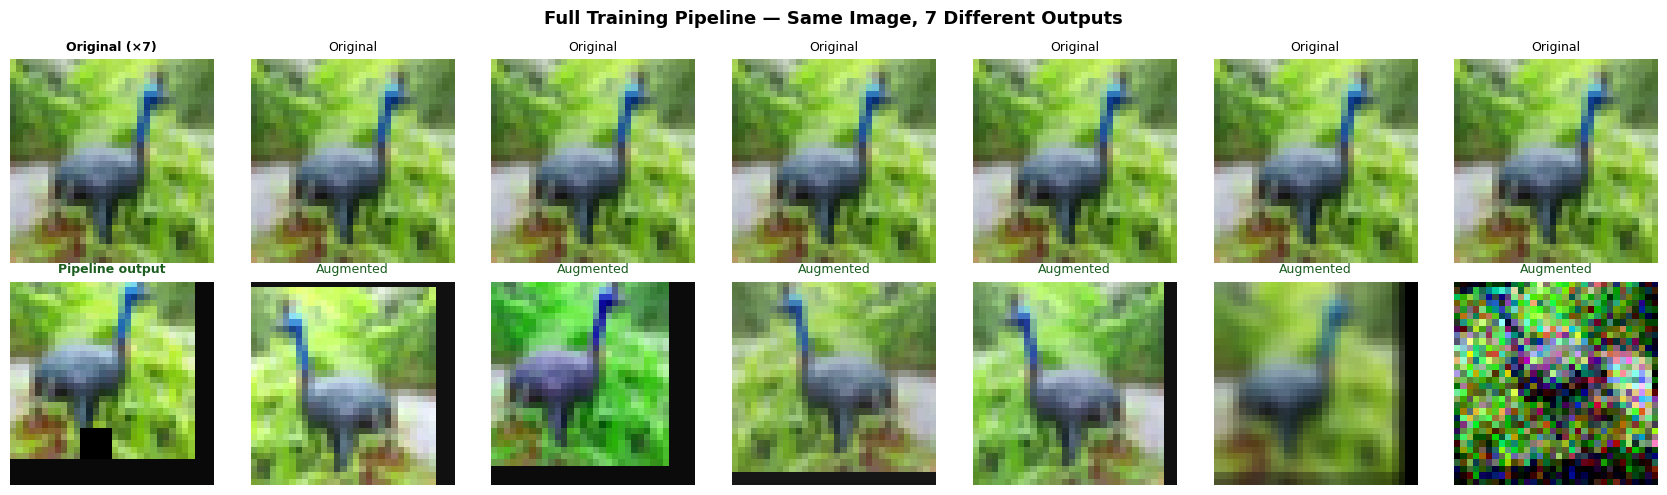

In [53]:
# Visualise the full pipeline — what does a training image look like after the pipeline?
img_raw, label = get_numpy_image(raw_train, DEMO_IDX)

np.random.seed(99)
fig, axes = plt.subplots(2, 7, figsize=(17, 5))

# Top row: raw images
for ax in axes[0]:
    ax.imshow(img_raw)
    ax.set_title('Original', fontsize=9)
    ax.axis('off')

# Bottom row: augmented output (post-pipeline, denormalised for display)
for ax in axes[1]:
    aug = train_transform(image=img_raw.copy())
    t = aug['image'].permute(1, 2, 0).numpy()
    # Denormalise for display
    mean = np.array(CIFAR_MEAN); std = np.array(CIFAR_STD)
    t = np.clip(t * std + mean, 0, 1)
    ax.imshow(t)
    ax.set_title('Augmented', fontsize=9, color='#1B5E20')
    ax.axis('off')

axes[0][0].set_title('Original (×7)', fontsize=9, fontweight='bold')
axes[1][0].set_title('Pipeline output', fontsize=9, fontweight='bold', color='#1B5E20')

plt.suptitle('Full Training Pipeline — Same Image, 7 Different Outputs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Custom Dataset Wrapper for Albumentations + PyTorch

Albumentations works on numpy arrays, but PyTorch's `DataLoader` expects a `Dataset` class. We need a thin wrapper that applies the Albumentations pipeline and returns the tensor PyTorch expects.

In [54]:
class CIFAR10Albumentation(Dataset):
    """
    Wraps the raw CIFAR-10 torchvision dataset to apply
    Albumentations transforms instead of torchvision transforms.
    """
    def __init__(self, torchvision_dataset, transform=None):
        self.dataset   = torchvision_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_tensor, label = self.dataset[idx]
        # Convert CHW tensor [0,1] → HWC numpy uint8 [0,255]
        img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=img_np)
            img_out   = augmented['image']   # already a CHW tensor (from ToTensorV2)
        else:
            img_out = img_tensor

        return img_out, label


BATCH = 128

# Dataset with augmentation
aug_train_ds  = CIFAR10Albumentation(raw_train, transform=train_transform)
aug_train_loader = DataLoader(aug_train_ds, batch_size=BATCH, shuffle=True, num_workers=0)

# Dataset WITHOUT augmentation (baseline)
base_train_ds = CIFAR10Albumentation(raw_train, transform=baseline_transform)
base_train_loader = DataLoader(base_train_ds, batch_size=BATCH, shuffle=True, num_workers=0)

# Test set — same for both experiments
test_ds     = CIFAR10Albumentation(raw_test, transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)

print(f'Augmented train loader : {len(aug_train_loader)} batches/epoch')
print(f'Baseline train loader  : {len(base_train_loader)} batches/epoch')
print(f'Test loader            : {len(test_loader)} batches')

Augmented train loader : 391 batches/epoch
Baseline train loader  : 391 batches/epoch
Test loader            : 79 batches


---
## 8. Model & Training Setup

We use a lightweight CNN — the same architecture for both experiments so the only variable is the augmentation pipeline. Keeping the model identical ensures any accuracy difference is purely from augmentation.

In [55]:
class LightCNN(nn.Module):
    """Small 3-block CNN — simple enough to train fast, complex enough to overfit without augmentation."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.3),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.4),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

tmp = LightCNN()
print(f'Model parameters: {count_params(tmp):,}')


def train_model(train_loader, epochs=10, label=''):
    model = LightCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f'\nTraining: {label}')
    print(f'{'Ep':>3} | {'Tr Loss':>7} | {'Tr Acc':>6} | {'Val Loss':>8} | {'Val Acc':>7}')
    print('-' * 45)

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        tr_loss, tr_correct = 0.0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tr_loss    += loss.item() * imgs.size(0)
            tr_correct += (out.argmax(1) == labels).sum().item()
        scheduler.step()

        # Evaluate
        model.eval()
        vl_loss, vl_correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, labels)
                vl_loss    += loss.item() * imgs.size(0)
                vl_correct += (out.argmax(1) == labels).sum().item()

        tr_l = tr_loss / len(train_loader.dataset)
        vl_l = vl_loss / len(test_loader.dataset)
        tr_a = tr_correct / len(train_loader.dataset)
        vl_a = vl_correct / len(test_loader.dataset)

        history['train_loss'].append(tr_l)
        history['train_acc'].append(tr_a)
        history['val_loss'].append(vl_l)
        history['val_acc'].append(vl_a)

        print(f'{epoch:>3} | {tr_l:>7.4f} | {tr_a:>5.1%} | {vl_l:>8.4f} | {vl_a:>6.1%}')

    print(f'Best val acc: {max(history["val_acc"]):.2%}')
    return history


print('Model and training function ready.')

Model parameters: 667,178
Model and training function ready.


---
## 9. Experiment: Baseline vs Augmented Training

Same model, same hyperparameters, same test set. Only difference: the training pipeline.

In [56]:
EPOCHS = 10

# Experiment 1: No augmentation
hist_base = train_model(base_train_loader, epochs=EPOCHS, label='No Augmentation (Baseline)')


Training: No Augmentation (Baseline)
 Ep | Tr Loss | Tr Acc | Val Loss | Val Acc
---------------------------------------------
  1 |  1.6654 | 38.3% |   1.2773 |  53.8%
  2 |  1.3473 | 51.0% |   1.0620 |  62.6%
  3 |  1.2029 | 57.2% |   0.9584 |  66.3%
  4 |  1.0997 | 61.1% |   0.8816 |  68.7%
  5 |  1.0297 | 63.9% |   0.8193 |  71.2%
  6 |  0.9647 | 66.1% |   0.8107 |  71.7%
  7 |  0.9213 | 67.7% |   0.7690 |  73.1%
  8 |  0.8782 | 69.3% |   0.7265 |  74.7%
  9 |  0.8534 | 70.1% |   0.7160 |  75.1%
 10 |  0.8439 | 70.6% |   0.7071 |  75.4%
Best val acc: 75.45%


In [60]:
# Experiment 2: With Albumentations pipeline
hist_aug = train_model(aug_train_loader, epochs=10, label='With Albumentations Pipeline')


Training: With Albumentations Pipeline
 Ep | Tr Loss | Tr Acc | Val Loss | Val Acc
---------------------------------------------
  1 |  1.9544 | 26.9% |   1.5716 |  41.9%
  2 |  1.7595 | 34.2% |   1.4108 |  47.9%
  3 |  1.6770 | 38.3% |   1.3281 |  50.8%
  4 |  1.6076 | 41.2% |   1.2576 |  53.4%
  5 |  1.5491 | 43.6% |   1.2071 |  55.1%
  6 |  1.5033 | 45.6% |   1.1336 |  58.6%
  7 |  1.4587 | 47.3% |   1.1214 |  58.5%
  8 |  1.4257 | 48.2% |   1.0687 |  61.1%
  9 |  1.4039 | 49.5% |   1.0569 |  61.5%
 10 |  1.4032 | 49.6% |   1.0507 |  61.5%
Best val acc: 61.54%


---
## 10. Results — What Did Augmentation Buy Us?

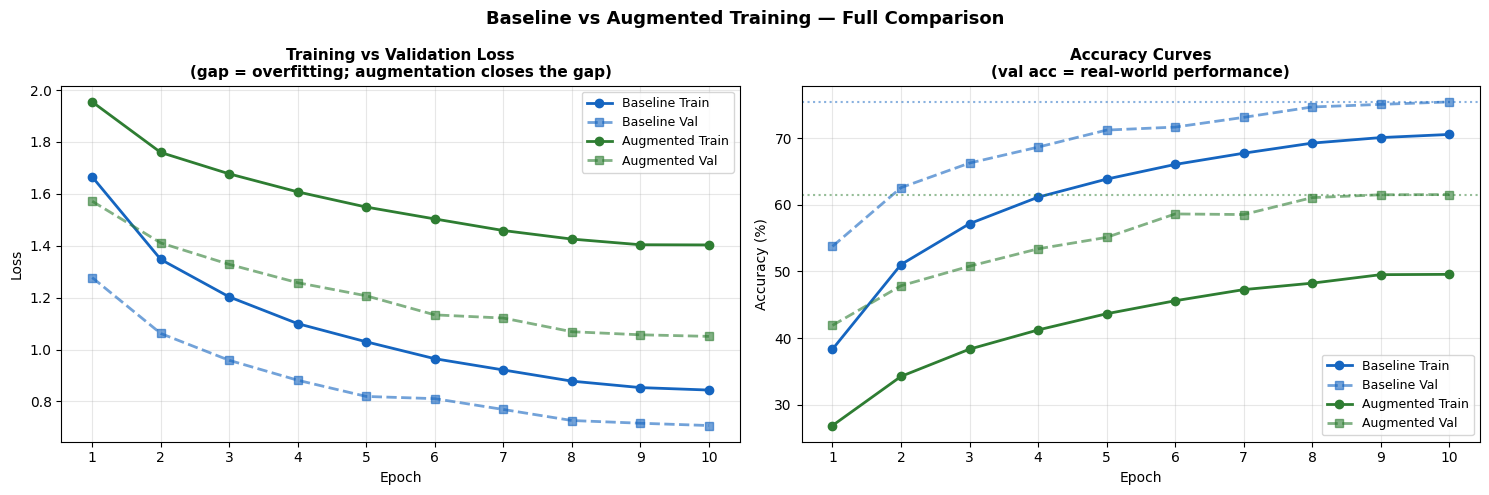

Baseline  best val accuracy : 75.45%
Augmented best val accuracy : 61.54%
Difference from augmentation: -13.91%


In [62]:
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Loss ---
ax = axes[0]
ax.plot(epochs_x, hist_base['train_loss'], 'o-',  color='#1565C0', lw=2, label='Baseline Train')
ax.plot(epochs_x, hist_base['val_loss'],   's--', color='#1565C0', lw=2, alpha=0.6, label='Baseline Val')
ax.plot(epochs_x, hist_aug['train_loss'],  'o-',  color='#2E7D32', lw=2, label='Augmented Train')
ax.plot(epochs_x, hist_aug['val_loss'],    's--', color='#2E7D32', lw=2, alpha=0.6, label='Augmented Val')
ax.set_title('Training vs Validation Loss\n(gap = overfitting; augmentation closes the gap)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(epochs_x)

# --- Accuracy ---
ax = axes[1]
ax.plot(epochs_x, [a*100 for a in hist_base['train_acc']], 'o-',  color='#1565C0', lw=2, label='Baseline Train')
ax.plot(epochs_x, [a*100 for a in hist_base['val_acc']],   's--', color='#1565C0', lw=2, alpha=0.6, label='Baseline Val')
ax.plot(epochs_x, [a*100 for a in hist_aug['train_acc']],  'o-',  color='#2E7D32', lw=2, label='Augmented Train')
ax.plot(epochs_x, [a*100 for a in hist_aug['val_acc']],    's--', color='#2E7D32', lw=2, alpha=0.6, label='Augmented Val')

best_base = max(hist_base['val_acc']) * 100
best_aug  = max(hist_aug['val_acc'])  * 100
ax.axhline(best_base, color='#1565C0', linestyle=':', lw=1.5, alpha=0.5)
ax.axhline(best_aug,  color='#2E7D32', linestyle=':', lw=1.5, alpha=0.5)

ax.set_title('Accuracy Curves\n(val acc = real-world performance)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(epochs_x)

plt.suptitle('Baseline vs Augmented Training — Full Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Baseline  best val accuracy : {best_base:.2f}%')
print(f'Augmented best val accuracy : {best_aug:.2f}%')
print(f'Difference from augmentation: {best_aug - best_base:.2f}%')

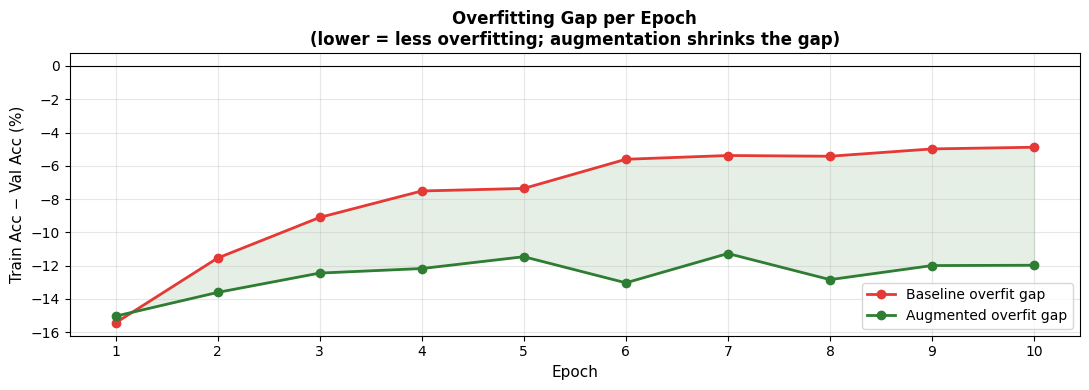

In [63]:
# --- Overfitting gap chart ---
# The gap between train acc and val acc = how much the model overfits.


base_gap = [((tr - vl) * 100) for tr, vl in zip(hist_base['train_acc'], hist_base['val_acc'])]
aug_gap  = [((tr - vl) * 100) for tr, vl in zip(hist_aug['train_acc'],  hist_aug['val_acc'])]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(epochs_x, base_gap, 'o-',  color='#E53935', lw=2, label='Baseline overfit gap')
ax.plot(epochs_x, aug_gap,  'o-',  color='#2E7D32', lw=2, label='Augmented overfit gap')
ax.fill_between(epochs_x, base_gap, aug_gap, alpha=0.12, color='#2E7D32')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Train Acc − Val Acc (%)', fontsize=11)
ax.set_title('Overfitting Gap per Epoch\n(lower = less overfitting; augmentation shrinks the gap)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xticks(epochs_x)
plt.tight_layout()
plt.show()

---
## 11. Augmentation Strategy Guide — When to Use What

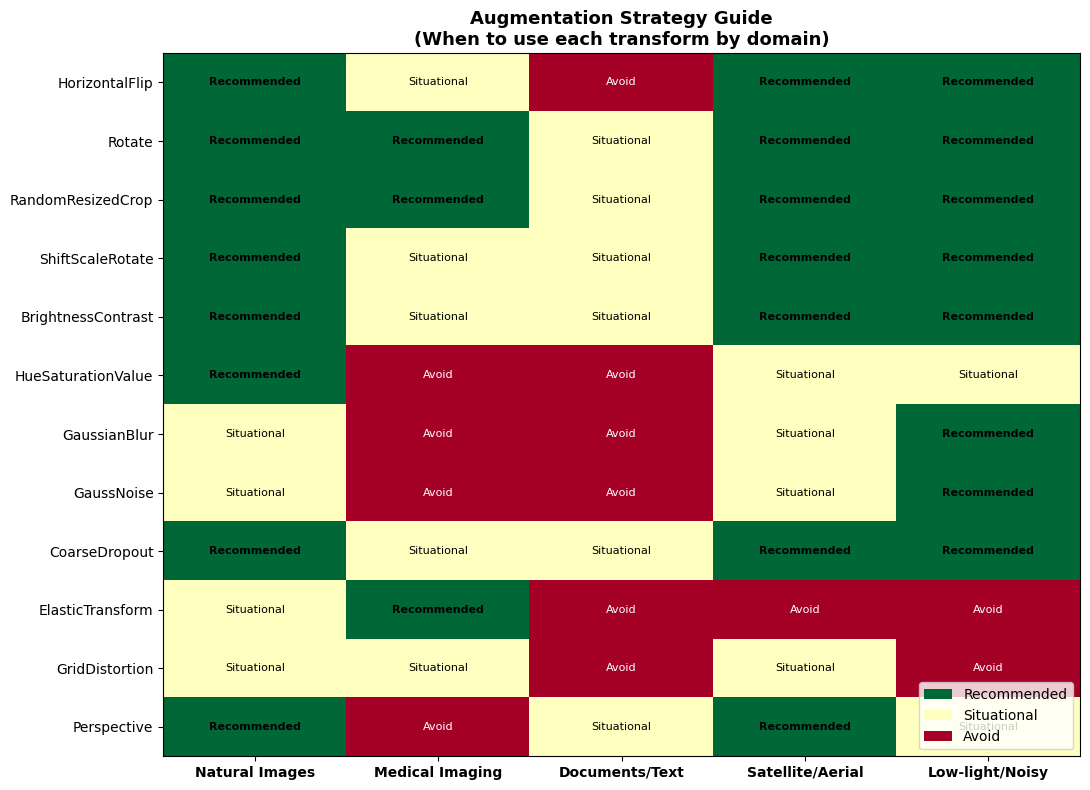

In [64]:
# Visual reference: transform type × use-case matrix
transforms_list = [
    'HorizontalFlip', 'Rotate', 'RandomResizedCrop', 'ShiftScaleRotate',
    'BrightnessContrast', 'HueSaturationValue', 'GaussianBlur', 'GaussNoise',
    'CoarseDropout', 'ElasticTransform', 'GridDistortion', 'Perspective'
]
use_cases = ['Natural Images', 'Medical Imaging', 'Documents/Text', 'Satellite/Aerial', 'Low-light/Noisy']

# 2 = strongly recommended, 1 = situational, 0 = avoid
matrix = np.array([
    [2, 1, 0, 2, 2],  # HorizontalFlip
    [2, 2, 1, 2, 2],  # Rotate
    [2, 2, 1, 2, 2],  # RandomResizedCrop
    [2, 1, 1, 2, 2],  # ShiftScaleRotate
    [2, 1, 1, 2, 2],  # BrightnessContrast
    [2, 0, 0, 1, 1],  # HueSaturationValue
    [1, 0, 0, 1, 2],  # GaussianBlur
    [1, 0, 0, 1, 2],  # GaussNoise
    [2, 1, 1, 2, 2],  # CoarseDropout
    [1, 2, 0, 0, 0],  # ElasticTransform
    [1, 1, 0, 1, 0],  # GridDistortion
    [2, 0, 1, 2, 1],  # Perspective
])

fig, ax = plt.subplots(figsize=(11, 8))
cmap = plt.cm.get_cmap('RdYlGn', 3)
im = ax.imshow(matrix, cmap=cmap, vmin=-0.5, vmax=2.5, aspect='auto')

for i in range(len(transforms_list)):
    for j in range(len(use_cases)):
        val = matrix[i, j]
        text = {2: 'Recommended', 1: 'Situational', 0: 'Avoid'}[val]
        ax.text(j, i, text, ha='center', va='center', fontsize=8,
                color='white' if val == 0 else 'black', fontweight='bold' if val == 2 else 'normal')

ax.set_xticks(range(len(use_cases))); ax.set_xticklabels(use_cases, fontsize=10, fontweight='bold')
ax.set_yticks(range(len(transforms_list))); ax.set_yticklabels(transforms_list, fontsize=10)
ax.set_title('Augmentation Strategy Guide\n(When to use each transform by domain)',
             fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend = [
    Patch(facecolor=cmap(2), label='Recommended'),
    Patch(facecolor=cmap(1), label='Situational'),
    Patch(facecolor=cmap(0), label='Avoid'),
]
ax.legend(handles=legend, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

---
## 12. Summary & Key Takeaways

**What augmentation does:**
Augmentation is not about faking more data — it's about making the model see the *same data from more angles*. It directly attacks overfitting by preventing the model from memorising exact pixel values.

**Why Albumentations:**
- Significantly faster than torchvision transforms (especially on CPU)
- 70+ transforms with consistent API
- `A.Compose`, `A.OneOf`, `A.SomeOf` for powerful pipeline composition
- Handles bounding boxes and segmentation masks too — same transform, all annotations updated

**The three rules of augmentation pipelines:**
1. Only augment training data — never test/validation images
2. Augmentations must preserve the label (a flipped cat is still a cat; a text image rotated 90° may not be readable)
3. Always `Normalize` + `ToTensorV2` at the very end

**Where to go next:**
- **MixUp / CutMix** — blend two images and their labels together (very effective on CIFAR)
- **AutoAugment / RandAugment** — automatically search for the best augmentation policy
- **TrivialAugmentWide** — state-of-the-art, no tuning required
- **Albumentations with bounding boxes** — same pipeline, works for object detection too

In [66]:
print('='*50)
print('        EXPERIMENT SCORECARD')
print('='*50)
print(f'Dataset         : CIFAR-10 (50k train / 10k test)')
print(f'Model           : LightCNN  ({count_params(LightCNN()):,} params)')
print(f'Epochs          : {EPOCHS}')
print(f'Batch size      : {BATCH}')
print()
print(f'Baseline val acc  (no aug) : {max(hist_base["val_acc"]):.2%}')
print(f'Augmented val acc          : {max(hist_aug["val_acc"]):.2%}')
print(f'loss from augmentation     : {(max(hist_aug["val_acc"]) - max(hist_base["val_acc"]))*100:.2f}%')
print()
final_base_gap = (hist_base['train_acc'][-1] - hist_base['val_acc'][-1]) * 100
final_aug_gap  = (hist_aug['train_acc'][-1]  - hist_aug['val_acc'][-1])  * 100
print(f'Final overfit gap (baseline)  : {final_base_gap:.1f}%')
print(f'Final overfit gap (augmented) : {final_aug_gap:.1f}%')
print('='*50)

        EXPERIMENT SCORECARD
Dataset         : CIFAR-10 (50k train / 10k test)
Model           : LightCNN  (667,178 params)
Epochs          : 10
Batch size      : 128

Baseline val acc  (no aug) : 75.45%
Augmented val acc          : 61.54%
loss from augmentation     : -13.91%

Final overfit gap (baseline)  : -4.9%
Final overfit gap (augmented) : -12.0%
